### Importando e carregando as Bibliotecas

In [7]:
import cv2
import matplotlib.pyplot as plt
import os
import glob

### Sprint 2

In [8]:
# 1. Definindo os caminhos das pastas
RAW_DIR = "raw_images"
PROCESSED_DIR = "processed_images"

# 2. Criando o padrão de busca para ler as subpastas em lote (Batch)
search_path_def = os.path.join(RAW_DIR, "def_front", "*.jpeg")
search_path_ok = os.path.join(RAW_DIR, "ok_front", "*.jpeg")

# 3. Combinando a lista de caminhos de todas as imagens encontradas
image_paths = glob.glob(search_path_def) + glob.glob(search_path_ok)

print(f"Total de imagens encontradas para processamento: {len(image_paths)}")

# 4. Teste de leitura estruturada da primeira imagem para validar o OpenCV
if len(image_paths) > 0:
    img_teste = cv2.imread(image_paths[0])
    print("\nSucesso! Primeira imagem carregada com o OpenCV.")
    print(f"Caminho do arquivo: {image_paths[0]}")
    print(f"Dimensões originais da imagem (Altura, Largura, Canais): {img_teste.shape}")
else:
    print("\nNenhuma imagem encontrada!")
    print(f"Certifique-se de que copiou as pastas 'def_front' e 'ok_front' com as fotos para dentro de: {os.path.abspath(RAW_DIR)}")


Total de imagens encontradas para processamento: 1300

Sucesso! Primeira imagem carregada com o OpenCV.
Caminho do arquivo: raw_images\def_front\cast_def_0_0.jpeg
Dimensões originais da imagem (Altura, Largura, Canais): (512, 512, 3)


### Sprint 3 
## Pipeline de Pré-processamento Base

Dimensões da imagem original: (512, 512, 3)
Dimensões da imagem em escala de cinza: (512, 512)
Filtro Gaussian Blur aplicado com sucesso.


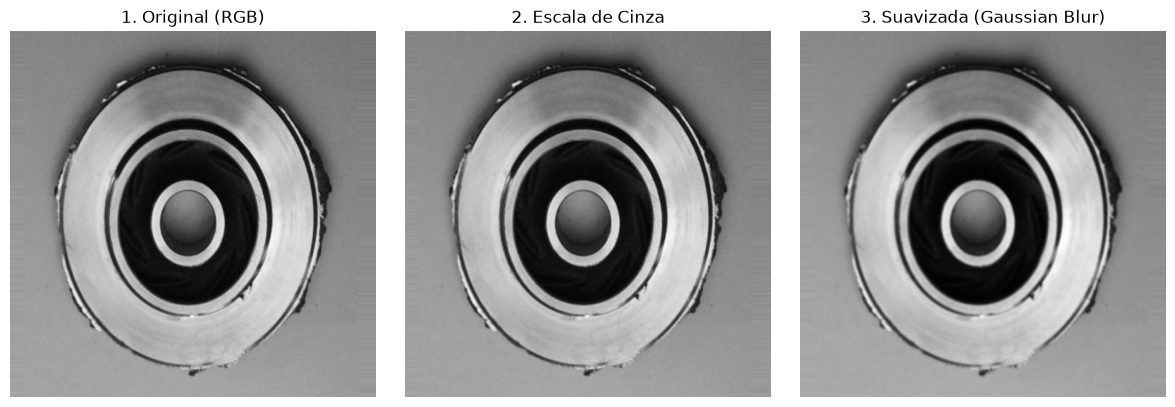

In [9]:
# Pegando apenas a primeira imagem carregada para o teste de pré-processamento
if len(image_paths) > 0:
    # Converter a imagem de BGR para Escala de Cinza
    gray_image = cv2.cvtColor(img_teste, cv2.COLOR_BGR2GRAY)
    
    # Aplicar redução de ruído usando o Gaussian Blur (Filtro de tamanho 5x5)
    blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
    print(f"Dimensões da imagem original: {img_teste.shape}")
    print(f"Dimensões da imagem em escala de cinza: {gray_image.shape}")
    print("Filtro Gaussian Blur aplicado com sucesso.")
    
    # Exibir visualmente os resultados intermediários
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img_teste, cv2.COLOR_BGR2RGB))
    plt.title("1. Original (RGB)")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(gray_image, cmap="gray")
    plt.title("2. Escala de Cinza")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(blurred_image, cmap="gray")
    plt.title("3. Suavizada (Gaussian Blur)")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma imagem carregada para processar.")


### SPRINT 4
# Segmentação e Destaque de Características

Limiarização de Otsu e Detecção de Bordas Canny executadas com sucesso.


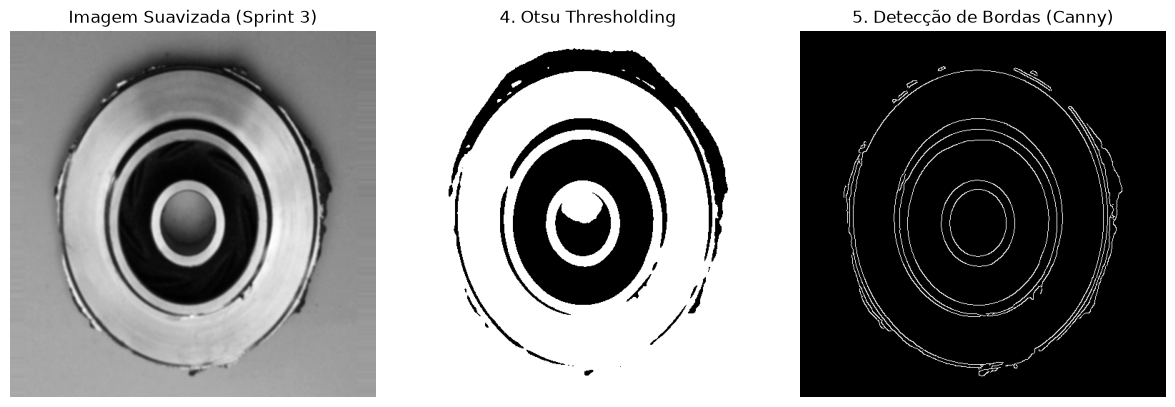

In [10]:
# Aplicar Limiarização Global pelo Método de Otsu na imagem suavizada
# O método calcula automaticamente o melhor limiar (threshold) binarizando a imagem
_, otsu_thresh = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Aplicar o algoritmo de Canny para detecção de bordas estruturais
# Passamos os limiares de gradiente mínimo (50) e máximo (150) para mapear os contornos
canny_edges = cv2.Canny(blurred_image, 50, 150)

print("Limiarização de Otsu e Detecção de Bordas Canny executadas com sucesso.")

# Exibir visualmente os resultados obtidos
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(blurred_image, cmap="gray")
plt.title("Imagem Suavizada (Sprint 3)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(otsu_thresh, cmap="gray")
plt.title("4. Otsu Thresholding")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canny_edges, cmap="gray")
plt.title("5. Detecção de Bordas (Canny)")
plt.axis("off")

plt.tight_layout()
plt.show()


### SPRINT 5 
# Refinamento Morfológico e Padronização

Dimensões antes do redimensionamento: (512, 512)
Dimensões finais padronizadas: (256, 256)
Operações morfológicas e redimensionamento concluídos com sucesso.


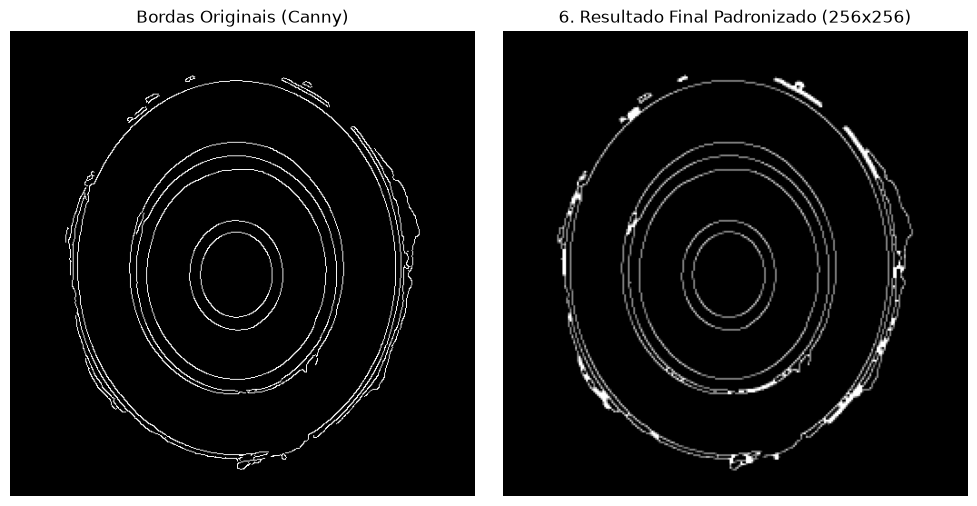

In [11]:
# Definir um elemento estruturante (kernel) quadrado de 3x3 pixels
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Aplicar Dilatação seguida de Erosão (Fechamento) para conectar ranhuras próximas e remover pequenos vazios
dilated_image = cv2.dilate(canny_edges, kernel, iterations=1)
morf_image = cv2.erode(dilated_image, kernel, iterations=1)

# Redimensionar a imagem resultante para o tamanho padrão exigido (256x256 pixels)
standardized_image = cv2.resize(morf_image, (256, 256))

print(f"Dimensões antes do redimensionamento: {morf_image.shape}")
print(f"Dimensões finais padronizadas: {standardized_image.shape}")
print("Operações morfológicas e redimensionamento concluídos com sucesso.")

# Exibir o resultado final do pré-processamento
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(canny_edges, cmap="gray")
plt.title("Bordas Originais (Canny)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(standardized_image, cmap="gray")
plt.title("6. Resultado Final Padronizado (256x256)")
plt.axis("off")

plt.tight_layout()
plt.show()


### SPRINT 6
# Processamento em Lote e Gravação dos Resultados

In [12]:
# Reconfigurando caminhos
RAW_DIR = "raw_images"
PROCESSED_DIR = "processed_images"

# Buscar todas as imagens originais (.jpeg) nas duas subpastas
search_path_def = os.path.join(RAW_DIR, "def_front", "*.jpeg")
search_path_ok = os.path.join(RAW_DIR, "ok_front", "*.jpeg")
all_image_paths = glob.glob(search_path_def) + glob.glob(search_path_ok)

print(f"Iniciando o processamento em lote para {len(all_image_paths)} imagens...")

# Loop por todas as imagens do dataset
for idx, img_path in enumerate(all_image_paths):
    # 1. Leitura
    img = cv2.imread(img_path)
    
    # 2. Pipeline completo (Sprints 3, 4 e 5)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    canny = cv2.Canny(blur, 50, 150)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    dilated = cv2.dilate(canny, kernel, iterations=1)
    morf = cv2.erode(dilated, kernel, iterations=1)
    
    resized = cv2.resize(morf, (256, 256))
    
    # 3. Identificar a subpasta original (def_front ou ok_front)
    subfolder_name = os.path.basename(os.path.dirname(img_path))
    
    # Criar a subpasta de saída correspondente dentro de processed_images
    output_subfolder = os.path.join(PROCESSED_DIR, subfolder_name)
    os.makedirs(output_subfolder, exist_ok=True)
    
    # 4. Gravação do arquivo final tratado
    filename = os.path.basename(img_path)
    output_path = os.path.join(output_subfolder, filename)
    cv2.imwrite(output_path, resized)

print("Sucesso! Todas as imagens foram processadas e salvas na pasta 'processed_images'.")


Iniciando o processamento em lote para 1300 imagens...
Sucesso! Todas as imagens foram processadas e salvas na pasta 'processed_images'.
